Question 1: Train a Logistic Regression Model

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


Question 2: Plot ROC Curve and Display AUC

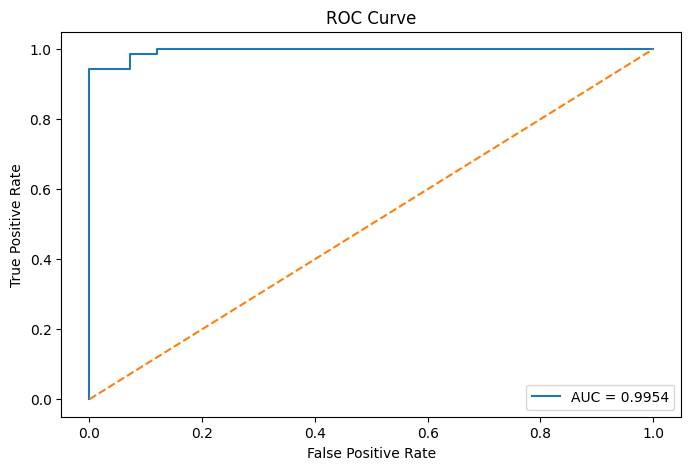

In [2]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

probabilities = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    probabilities
)

auc_score = roc_auc_score(
    y_test,
    probabilities
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

Question 3: Precision-Recall Curve

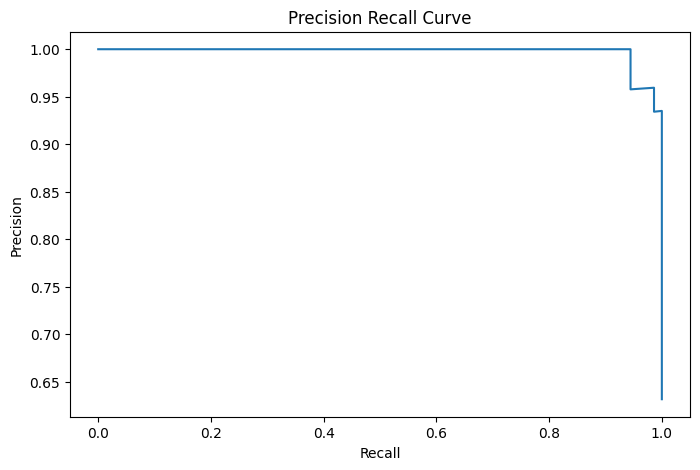

In [3]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(8,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

Question 4: Calculate Log Loss

In [5]:
from sklearn.metrics import log_loss

loss = log_loss(
    y_test,
    probabilities
)

print("Log Loss:", loss)

Log Loss: 0.08941656789497213


Question 5: Make the Test Set More Imbalanced

In [6]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss

positive_indices = np.where(y_test == 1)[0][:2]

negative_indices = np.where(y_test == 0)[0]

selected_indices = np.concatenate(
    [positive_indices, negative_indices]
)

X_test_imbalanced = X_test[selected_indices]

y_test_imbalanced = y_test[selected_indices]

probabilities_imbalanced = model.predict_proba(
    X_test_imbalanced
)[:, 1]

predictions_imbalanced = model.predict(
    X_test_imbalanced
)

accuracy = accuracy_score(
    y_test_imbalanced,
    predictions_imbalanced
)

auc = roc_auc_score(
    y_test_imbalanced,
    probabilities_imbalanced
)

loss = log_loss(
    y_test_imbalanced,
    probabilities_imbalanced
)

print("Accuracy:", accuracy)

print("AUC:", auc)

print("Log Loss:", loss)

Accuracy: 0.9318181818181818
AUC: 0.9642857142857143
Log Loss: 0.12384413316015772
